In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
import wavelet_funcs as wf

## Constant signal - CWT coefficients must be zero

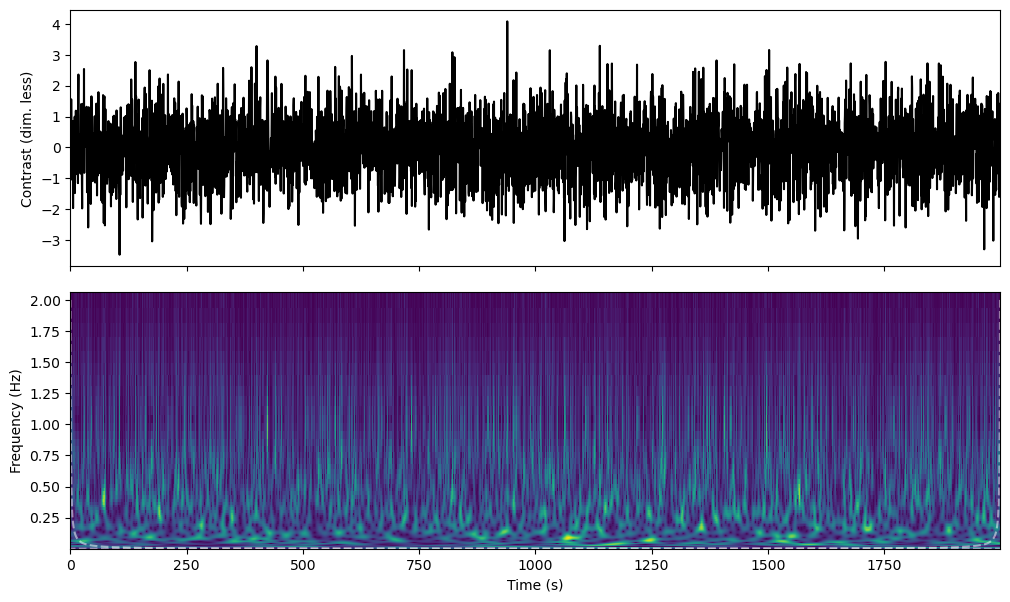

In [3]:
fs = 2
T = 2000
t = np.arange(0, T, 1/fs)
s = np.random.randn(t.size)

_, (ax,ax1) = wf.plot_timeseries_and_its_cwt(s, t, f1=1/T, f2=fs/1, method='fft', show_smoothed=False, precision=16)

In [4]:
res = wf.cwt_with_coi(s, t, 1/T, fs/2, method='fft', precision=16)

In [5]:
x = abs(res.wt_coefs).mean('t')

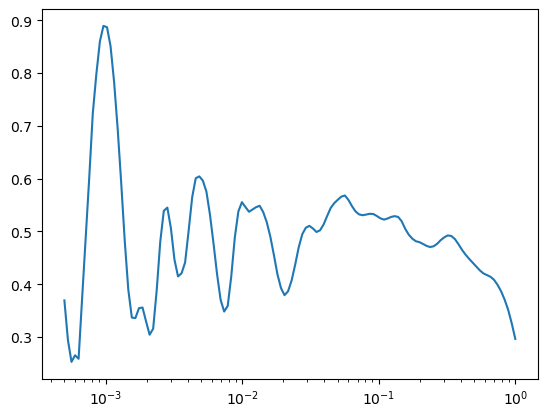

In [6]:
plt.semilogx(res.f, x)

## Ssqueezepy

In [8]:
import ssqueezepy as sq

In [9]:
wav = sq.Wavelet(('morlet', {'mu': 5}))
Tx, Wx, freqs, scales = sq.ssq_cwt(s, wavelet=wav, fs=fs,  nv=16)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

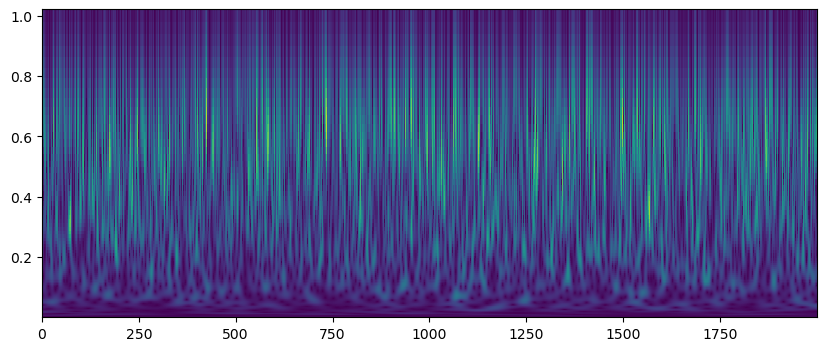

In [10]:
wf.plot_cwt(abs(Wx), freqs, t)
# plt.ylim(1/T,0.02)

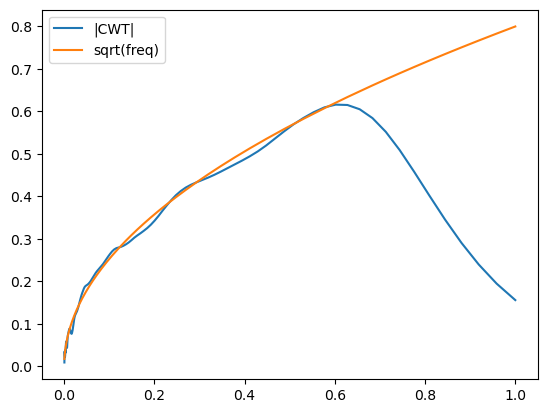

In [11]:
y = abs(Wx).mean(axis=1)

plt.plot(freqs, y, label='|CWT|')
plt.plot(freqs, np.sqrt(freqs)/1.25, label='sqrt(freq)')
plt.legend()

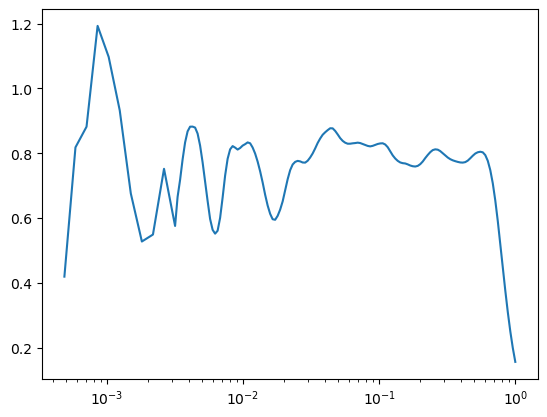

In [12]:
plt.semilogx(freqs, y/np.sqrt(freqs))